### Imports

In [20]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Advertising

In [21]:
# Cargar los datos desde el archivo CSV
data = pd.read_csv('Advertising.csv')
data = data.drop(columns=['Unnamed: 0'])

## 1. Correlación

                 TV     Radio  Newspaper     Sales
TV         1.000000  0.054809   0.056648  0.782224
Radio      0.054809  1.000000   0.354104  0.576223
Newspaper  0.056648  0.354104   1.000000  0.228299
Sales      0.782224  0.576223   0.228299  1.000000


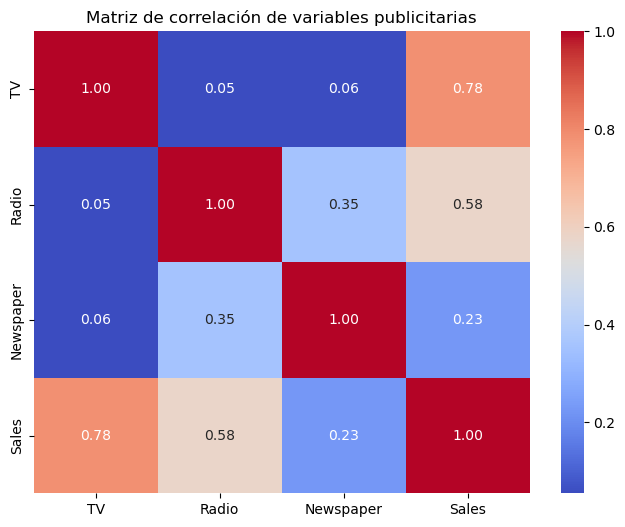

In [22]:
# Calcular la matriz de correlación
correlation_matrix = data.corr()

# Mostrar la matriz de correlación
print(correlation_matrix)

# Visualizar la matriz de correlación usando un heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de correlación de variables publicitarias')
plt.show()

## 2. Regresión Simple

In [23]:
# Definir las variables independientes y dependientes
X_tv = data[['TV']]
X_radio = data[['Radio']]
X_newspaper = data[['Newspaper']]
y = data['Sales']

# Crear modelos de regresión lineal
model_tv = LinearRegression()
model_radio = LinearRegression()
model_newspaper = LinearRegression()

# Ajustar los modelos
model_tv.fit(X_tv, y)
model_radio.fit(X_radio, y)
model_newspaper.fit(X_newspaper, y)

# Realizar predicciones
y_pred_tv = model_tv.predict(X_tv)
y_pred_radio = model_radio.predict(X_radio)
y_pred_newspaper = model_newspaper.predict(X_newspaper)

# Evaluar el rendimiento de los modelos
mse_tv = mean_squared_error(y, y_pred_tv)
mse_radio = mean_squared_error(y, y_pred_radio)
mse_newspaper = mean_squared_error(y, y_pred_newspaper)

r2_tv = r2_score(y, y_pred_tv)
r2_radio = r2_score(y, y_pred_radio)
r2_newspaper = r2_score(y, y_pred_newspaper)

In [24]:
# Mostrar resultados
print("Modelo de regresión para TV:")
print(f"Coeficiente: {model_tv.coef_[0]}")
print(f"Intercepto: {model_tv.intercept_}")
print(f"MSE: {mse_tv}")
print(f"R^2: {r2_tv}\n")

print("Modelo de regresión para Radio:")
print(f"Coeficiente: {model_radio.coef_[0]}")
print(f"Intercepto: {model_radio.intercept_}")
print(f"MSE: {mse_radio}")
print(f"R^2: {r2_radio}\n")

print("Modelo de regresión para Newspaper:")
print(f"Coeficiente: {model_newspaper.coef_[0]}")
print(f"Intercepto: {model_newspaper.intercept_}")
print(f"MSE: {mse_newspaper}")
print(f"R^2: {r2_newspaper}\n")

Modelo de regresión para TV:
Coeficiente: 0.047536640433019764
Intercepto: 7.032593549127693
MSE: 10.512652915656757
R^2: 0.611875050850071

Modelo de regresión para Radio:
Coeficiente: 0.20249578339243968
Intercepto: 9.311638095158283
MSE: 18.09239774512544
R^2: 0.33203245544529525

Modelo de regresión para Newspaper:
Coeficiente: 0.05469309847227335
Intercepto: 12.351407069278162
MSE: 25.674022720559698
R^2: 0.05212044544430516



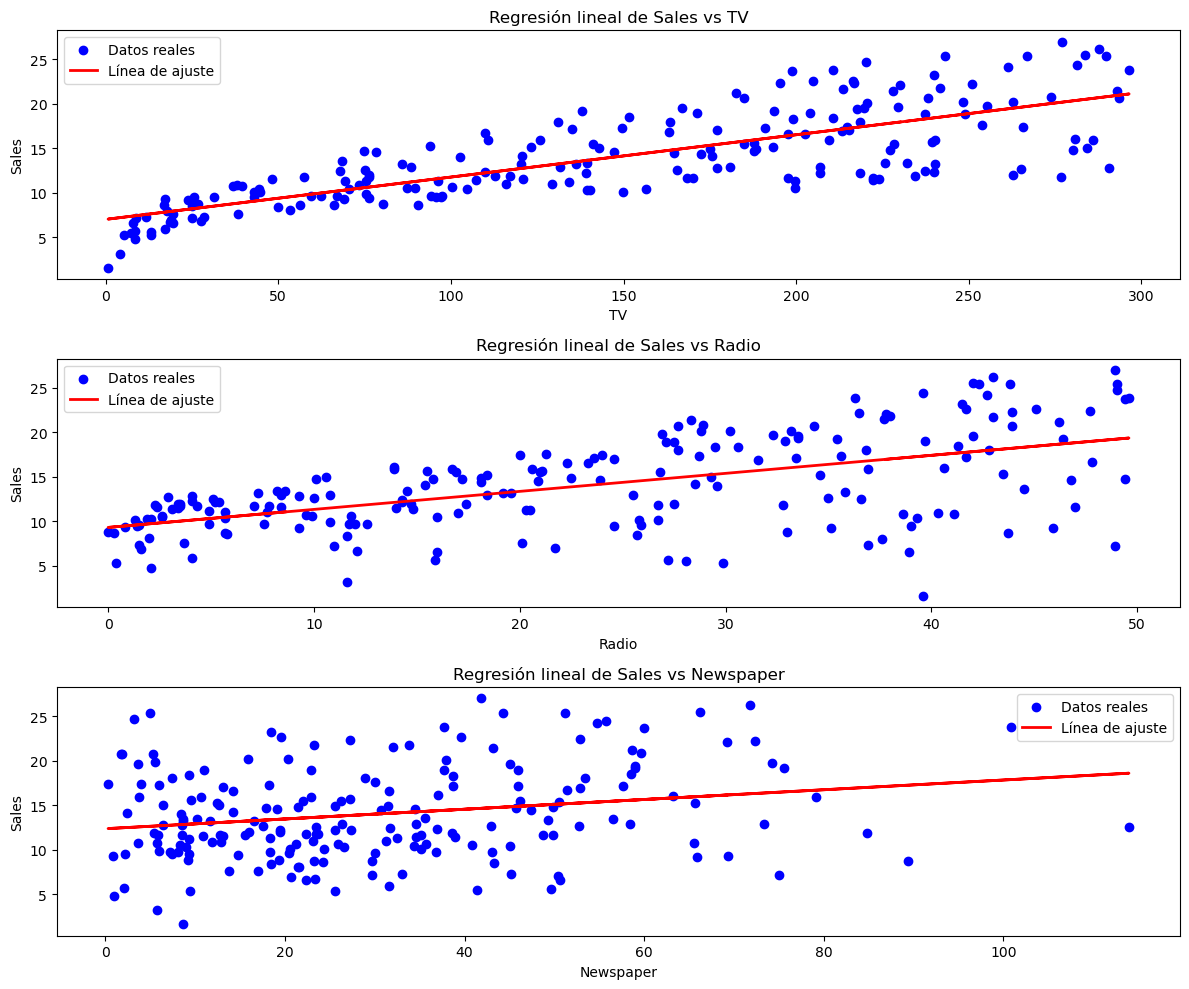

In [25]:
# Visualizar los resultados
plt.figure(figsize=(12, 10))

# TV vs Sales
plt.subplot(3, 1, 1)
plt.scatter(X_tv, y, color='blue', label='Datos reales')
plt.plot(X_tv, y_pred_tv, color='red', linewidth=2, label='Línea de ajuste')
plt.xlabel('TV')
plt.ylabel('Sales')
plt.title('Regresión lineal de Sales vs TV')
plt.legend()

# Radio vs Sales
plt.subplot(3, 1, 2)
plt.scatter(X_radio, y, color='blue', label='Datos reales')
plt.plot(X_radio, y_pred_radio, color='red', linewidth=2, label='Línea de ajuste')
plt.xlabel('Radio')
plt.ylabel('Sales')
plt.title('Regresión lineal de Sales vs Radio')
plt.legend()

# Newspaper vs Sales
plt.subplot(3, 1, 3)
plt.scatter(X_newspaper, y, color='blue', label='Datos reales')
plt.plot(X_newspaper, y_pred_newspaper, color='red', linewidth=2, label='Línea de ajuste')
plt.xlabel('Newspaper')
plt.ylabel('Sales')
plt.title('Regresión lineal de Sales vs Newspaper')
plt.legend()

plt.tight_layout()
plt.show()

## 3. Regresión Múltiple

In [26]:
# Definir las variables independientes y dependientes
X = data[['TV', 'Radio', 'Newspaper']]
y = data['Sales']

# Crear el modelo de regresión lineal múltiple
model_multiple = LinearRegression()

# Ajustar el modelo
model_multiple.fit(X, y)

# Realizar predicciones
y_pred_multiple = model_multiple.predict(X)

# Evaluar el rendimiento del modelo
mse_multiple = mean_squared_error(y, y_pred_multiple)
r2_multiple = r2_score(y, y_pred_multiple)

In [27]:
# Mostrar resultados
print("Modelo de regresión lineal múltiple:")
print(f"Coeficientes: {model_multiple.coef_}")
print(f"Intercepto: {model_multiple.intercept_}")
print(f"MSE: {mse_multiple}")
print(f"R^2: {r2_multiple}")

Modelo de regresión lineal múltiple:
Coeficientes: [ 0.04576465  0.18853002 -0.00103749]
Intercepto: 2.9388893694594085
MSE: 2.784126314510936
R^2: 0.8972106381789522


## 4. Diagnóstico

### 4.1 Regresión Simple

In [28]:
# Definir las variables
X_simple = data['TV']
X_simple = sm.add_constant(X_simple)  # Agregar el intercepto
y = data['Sales']

# Ajustar el modelo
model_simple = sm.OLS(y, X_simple).fit()

# Resumen del modelo para obtener el p-valor del test t-student
print(model_simple.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.612
Model:                            OLS   Adj. R-squared:                  0.610
Method:                 Least Squares   F-statistic:                     312.1
Date:                Sat, 24 Aug 2024   Prob (F-statistic):           1.47e-42
Time:                        12:05:30   Log-Likelihood:                -519.05
No. Observations:                 200   AIC:                             1042.
Df Residuals:                     198   BIC:                             1049.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.0326      0.458     15.360      0.0

### 4.2 Regresión Múltiple

In [29]:
# Definir las variables
X_multiple = data[['TV', 'Radio', 'Newspaper']]
X_multiple = sm.add_constant(X_multiple)  # Agregar el intercepto

# Ajustar el modelo
model_multiple = sm.OLS(y, X_multiple).fit()

# Resumen del modelo para obtener el p-valor del test de Fisher
print(model_multiple.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     570.3
Date:                Sat, 24 Aug 2024   Prob (F-statistic):           1.58e-96
Time:                        12:05:30   Log-Likelihood:                -386.18
No. Observations:                 200   AIC:                             780.4
Df Residuals:                     196   BIC:                             793.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.9389      0.312      9.422      0.0

In [30]:
# Calcular el VIF para cada variable independiente
vif_data = pd.DataFrame()
vif_data['Feature'] = X_multiple.columns
vif_data['VIF'] = [variance_inflation_factor(X_multiple.values, i) for i in range(X_multiple.shape[1])]
print(vif_data)

     Feature       VIF
0      const  6.848900
1         TV  1.004611
2      Radio  1.144952
3  Newspaper  1.145187


## 5. Analizar la influencia de cada variable en las ventas

In [31]:
# Separar variables independientes y dependientes
X = data[['TV', 'Radio', 'Newspaper']]
y = data['Sales']

# Agregar una constante para el modelo
X = sm.add_constant(X)

Coeficientes, p-valores, y R²

In [32]:
# Modelo de regresión múltiple
model = sm.OLS(y, X).fit()

# Imprimir coeficientes y p-valores
print("Coeficientes del modelo:")
print(model.params)
print("\nP-valores:")
print(model.pvalues)

# R² y R² ajustado
print("\nR² del modelo:", model.rsquared)
print("R² ajustado del modelo:", model.rsquared_adj)

Coeficientes del modelo:
const        2.938889
TV           0.045765
Radio        0.188530
Newspaper   -0.001037
dtype: float64

P-valores:
const        1.267295e-17
TV           1.509960e-81
Radio        1.505339e-54
Newspaper    8.599151e-01
dtype: float64

R² del modelo: 0.8972106381789522
R² ajustado del modelo: 0.8956373316204668


Test de Fisher (para el modelo múltiple)

In [33]:
# Test F (para el modelo completo)
f_pvalue = model.f_pvalue
print("\nP-valor del Test F:", f_pvalue)


P-valor del Test F: 1.575227256092437e-96


VIF (Factor de Inflación de la Varianza)

In [34]:
# Calcular VIF para cada variable
vif = pd.DataFrame()
vif["Feature"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print("\nVIF de las variables:")
print(vif)


VIF de las variables:
     Feature       VIF
0      const  6.848900
1         TV  1.004611
2      Radio  1.144952
3  Newspaper  1.145187


## 6. Predicciones

### Dividir el conjunto de datos

In [35]:
# Separar las variables independientes (X) y la dependiente (y)
X = data[['TV', 'Radio', 'Newspaper']]
y = data['Sales']

# Dividir en conjuntos de entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Agregar una constante para los modelos
X_train = sm.add_constant(X_train)
X_test = sm.add_constant(X_test)

### Entrenar los modelos

In [36]:
# Entrenar el modelo de regresión múltiple
model = sm.OLS(y_train, X_train).fit()

### Predecir y calcular las métricas

In [37]:
# Predecir en el conjunto de prueba
y_pred = model.predict(X_test)

# Calcular MAE y MSE
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("MAE del modelo:", mae)
print("MSE del modelo:", mse)

MAE del modelo: 1.46075671681176
MSE del modelo: 3.1740973539761064
